In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/271 Final Project/fitzpatrick17k.csv')
df.head()

,md5hash,fitzpatrick_scale,fitzpatrick_centaur,label,nine_partition_label,three_partition_label,qc,url,url_alphanum
0,5e82a45bc5d78bd24ae9202d194423f8,3,3,drug induced pigmentary changes,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicmminoc...
1,fa2911a9b13b6f8af79cb700937cc14f,1,1,photodermatoses,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicpphoto...
2,d2bac3c9e4499032ca8e9b07c7d3bc40,2,3,dermatofibroma,benign dermal,benign,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicdderma...
3,0a94359e7eaacd7178e06b2823777789,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...
4,a39ec3b1f22c08a421fa20535e037bba,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...


In [ ]:
print(df['label'].unique())
print(df['label'].value_counts())

['drug induced pigmentary changes' 'photodermatoses' 'dermatofibroma'
 'psoriasis' 'kaposi sarcoma' 'neutrophilic dermatoses'
 'granuloma annulare' 'nematode infection' 'allergic contact dermatitis'
 'necrobiosis lipoidica' 'hidradenitis' 'melanoma' 'acne vulgaris'
 'sarcoidosis' 'xeroderma pigmentosum' 'actinic keratosis' 'scleroderma'
 'syringoma' 'folliculitis' 'pityriasis lichenoides chronica' 'porphyria'
 'dyshidrotic eczema' 'seborrheic dermatitis' 'prurigo nodularis' 'acne'
 'neurofibromatosis' 'eczema' 'pediculosis lids' 'basal cell carcinoma'
 'pityriasis rubra pilaris' 'pityriasis rosea' 'livedo reticularis'
 'stevens johnson syndrome' 'erythema multiforme'
 'acrodermatitis enteropathica' 'epidermolysis bullosa' 'dermatomyositis'
 'urticaria' 'basal cell carcinoma morpheiform' 'vitiligo'
 'erythema nodosum' 'lupus erythematosus' 'lichen planus'
 'sun damaged skin' 'drug eruption' 'scabies' 'cheilitis'
 'urticaria pigmentosa' 'behcets disease' 'nevocytic nevus'
 'mycosis fungo

In [ ]:
#count of images for light and dark skin tone groups
df['fitzpatrick_scale'].value_counts().sort_index()

df['tone_group'] = df['fitzpatrick_scale'].apply(lambda x: 'Dark (IV-VI)' if x >= 4 else 'Light (I-III)')
df['tone_group'].value_counts()

,count
tone_group,
Light (I-III),11628
Dark (IV-VI),4949


In [ ]:
#underrepresented labels in the darker IV-VI samples
darker_tone = df[df['fitzpatrick_scale'] >= 4].groupby('label').size()
print(darker_tone[darker_tone < 10].sort_values())

label
basal cell carcinoma morpheiform                         1
pilomatricoma                                            2
solid cystic basal cell carcinoma                        3
disseminated actinic porokeratosis                       6
langerhans cell histiocytosis                            6
perioral dermatitis                                      6
acquired autoimmune bullous diseaseherpes gestationis    7
dermatofibroma                                           8
aplasia cutis                                            8
nevocytic nevus                                          8
port wine stain                                          8
paronychia                                               9
rosacea                                                  9
superficial spreading melanoma ssm                       9
tick bite                                                9
dtype: int64


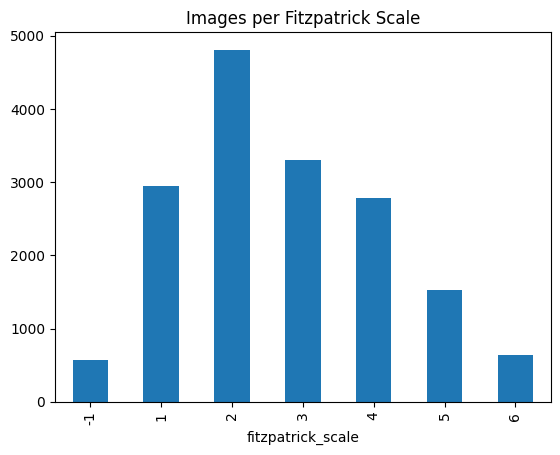

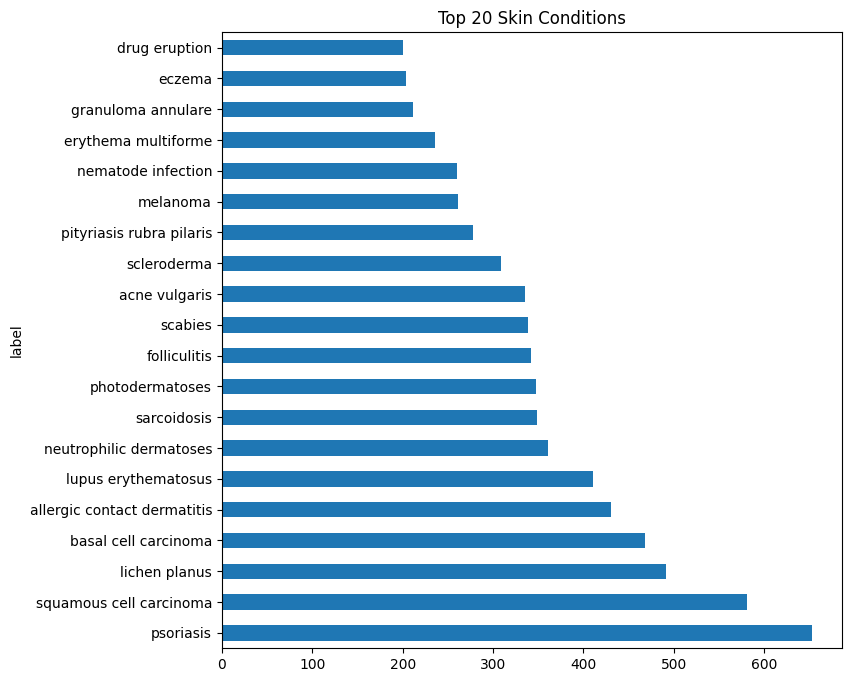

In [ ]:
import matplotlib.pyplot as plt

#fitpatrick scale distribution
df['fitzpatrick_scale'].value_counts().sort_index().plot(kind='bar')
plt.title('Images per Fitzpatrick Scale')
plt.show()

#most common labels
df['label'].value_counts().head(20).plot(kind='barh', figsize=(8,8))
plt.title('Top 20 Skin Conditions')
plt.show()

In [ ]:
df_dermaamin = df.dropna(subset=['fitzpatrick_scale', 'label']).copy()
df_dermaamin = df_dermaamin[df_dermaamin['url'].str.contains('dermaamin', na=False)]

print(f"Total DermaAmin rows: {len(df_dermaamin)}")
print(f"Unique labels: {df_dermaamin['label'].nunique()}")
print(f"Tone group split:\n{df_dermaamin['tone_group'].value_counts()}")

Total DermaAmin rows: 12631
Unique labels: 114
Tone group split:
tone_group
Light (I-III)    9624
Dark (IV-VI)     3007
Name: count, dtype: int64


In [ ]:
subset_size = 4500
per_group = subset_size // 2

def sample_group(group_df, n_total, seed=42):
    label_counts = group_df['label'].value_counts()
    n_labels = len(label_counts)
    base_per_label = n_total // n_labels

    sampled = []
    for label, count in label_counts.items():
        label_df = group_df[group_df['label'] == label]
        n_sample = min(count, max(1, base_per_label))
        sampled.append(label_df.sample(n=n_sample, random_state=42))

    return pd.concat(sampled)

light_df = df_dermaamin[df_dermaamin['tone_group'] == 'Light (I-III)']
dark_df  = df_dermaamin[df_dermaamin['tone_group'] == 'Dark (IV-VI)']

print(f"Available light: {len(light_df)}, Available dark: {len(dark_df)}")

per_group = min(per_group, len(light_df), len(dark_df))
print(f"Sampling {per_group} per group ({per_group*2} total)")

light_sample = sample_group(light_df, per_group, seed=42)
dark_sample  = sample_group(dark_df,  per_group, seed=42)

subset = pd.concat([light_sample, dark_sample]).drop_duplicates()

print(f"\nFinal subset size: {len(subset)}")
print(f"Light (I-III): {(subset['tone_group'] == 'Light (I-III)').sum()}")
print(f"Dark (IV-VI):  {(subset['tone_group'] == 'Dark (IV-VI)').sum()}")
print(f"Unique labels: {subset['label'].nunique()}")

Available light: 9624, Available dark: 3007
Sampling 2250 per group (4500 total)

Final subset size: 3884
Light (I-III): 2166
Dark (IV-VI):  1718
Unique labels: 114


In [ ]:
import requests
import os
from PIL import Image
from io import BytesIO
import time
from tqdm import tqdm

os.makedirs('/content/drive/MyDrive/271 Final Project/images', exist_ok=True)

URL_COL = 'url'
SAVE_DIR = '/content/drive/MyDrive/271 Final Project/images'

In [ ]:
failed_urls = []

for idx, row in tqdm(subset.iterrows(), total=len(subset)):
    filename = f"{row['md5hash']}.jpg"
    save_path = os.path.join(SAVE_DIR, filename)

    if os.path.exists(save_path):
        continue

    try:
        response = requests.get(row[URL_COL], headers=headers, timeout=10)
        img = Image.open(BytesIO(response.content)).convert('RGB')
        img.save(save_path)
        time.sleep(0.1)
    except Exception as e:
        print(f"Failed: {row[URL_COL]} — {e}")
        failed_urls.append(idx)

print(f"\nDownloaded: {len(subset) - len(failed_urls)}")
print(f"Failed: {len(failed_urls)}")

# Add image path to subset
subset['image_path'] = subset['md5hash'].apply(
    lambda h: os.path.join(SAVE_DIR, f"{h}.jpg")
              if os.path.exists(os.path.join(SAVE_DIR, f"{h}.jpg")) else None
)
print(f"Missing images: {subset['image_path'].isna().sum()}")

100%|██████████| 3884/3884 [1:13:01<00:00,  1.13s/it]



Downloaded: 3884
Failed: 0
Missing images: 0


In [ ]:
# #test subset
# test_subset = subset.head(5)

# for idx, row in test_subset.iterrows():
#     filename = f"{row['md5hash']}.jpg"
#     save_path = os.path.join(SAVE_DIR, filename)

#     try:
#         response = requests.get(row[URL_COL], headers=headers, timeout=10)
#         img = Image.open(BytesIO(response.content)).convert('RGB')
#         img.save(save_path)
#         print(f"✓ Saved: {filename}")
#     except Exception as e:
#         print(f"✗ Failed: {row[URL_COL]} — {e}")

In [ ]:
print(subset[URL_COL].apply(lambda x: 'atlasdermatologico' if 'atlasdermatologico' in str(x) else 'dermaamin').value_counts())

url
dermaamin             3181
atlasdermatologico     850
Name: count, dtype: int64


In [ ]:
subset_dermaamin = subset[subset[URL_COL].str.contains('dermaamin', na=False)].copy()
print(f"DermaAmin only subset: {len(subset_dermaamin)}")

DermaAmin only subset: 3171


In [ ]:
#correlate each image path in drive to respective row
subset['image_path'] = subset['md5hash'].apply(
    lambda h: os.path.join(SAVE_DIR, f"{h}.jpg")
              if os.path.exists(os.path.join(SAVE_DIR, f"{h}.jpg")) else None
)

print(f"Matched: {subset['image_path'].notna().sum()}")
subset[['md5hash', 'label', 'fitzpatrick_scale', 'tone_group', 'image_path']].head()
print(subset['tone_group'].value_counts())

Matched: 3884
tone_group
Light (I-III)    2166
Dark (IV-VI)     1718
Name: count, dtype: int64


In [ ]:
subset.to_csv('/content/drive/MyDrive/271 Final Project/subset_with_paths.csv', index=False)

In [18]:
!pip install open_clip_torch

import torch
import open_clip
from PIL import Image
import numpy as np
from tqdm import tqdm

model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
model.eval()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

embeddings = []
valid_indices = []

for idx, row in tqdm(subset.iterrows(), total=len(subset)):
    try:
        img = Image.open(row['image_path']).convert('RGB')
        img_tensor = preprocess(img).unsqueeze(0).to(device)

        with torch.no_grad():
            embedding = model.encode_image(img_tensor)
            embedding = embedding / embedding.norm(dim=-1, keepdim=True)  # normalize

        embeddings.append(embedding.cpu().numpy().squeeze())
        valid_indices.append(idx)
    except Exception as e:
        print(f"Failed: {row['image_path']} — {e}")

embeddings = np.array(embeddings)
print(f"Embeddings shape: {embeddings.shape}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.4 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
100%|██████████| 3884/3884 [35:24<00:00,  1.83it/s]

Embeddings shape: (3884, 512)


In [21]:
np.save('/content/drive/MyDrive/271 Final Project/embeddings.npy', embeddings)

subset_valid = subset.loc[valid_indices].copy()
subset_valid['embedding_idx'] = range(len(subset_valid))
subset_valid.to_csv('/content/drive/MyDrive/271 Final Project/subset_with_embeddings.csv', index=False)

In [22]:
print(f"Shape: {embeddings.shape}")
print(f"Sample embedding (first 10 dims): {embeddings[0][:10]}")

Shape: (3884, 512)
Sample embedding (first 10 dims): [-0.02068422 -0.00807459  0.0301485   0.03713837 -0.01013484  0.01471773
 -0.0307238   0.03702925  0.05345145 -0.01618182]


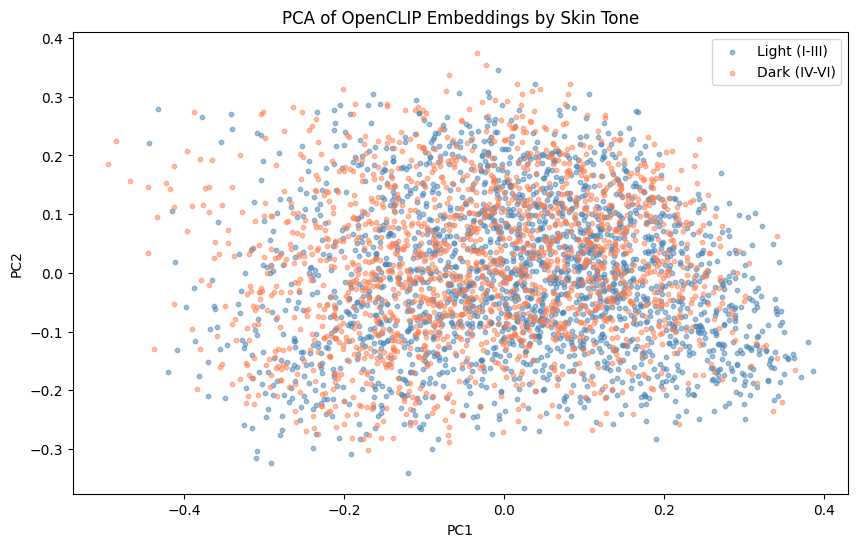

Variance explained: 16.09%


In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 6))
for group, color in [('Light (I-III)', 'steelblue'), ('Dark (IV-VI)', 'coral')]:
    mask = subset_valid['tone_group'].values == group
    plt.scatter(reduced[mask, 0], reduced[mask, 1], label=group, alpha=0.5, s=10, c=color)

plt.legend()
plt.title('PCA of OpenCLIP Embeddings by Skin Tone')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

print(f"Variance explained: {pca.explained_variance_ratio_.sum():.2%}")

In [24]:
subset_valid.to_csv('/content/drive/MyDrive/271 Final Project/subset_with_paths.csv', index=False)

In [26]:
#directly load embedddings
import numpy as np
import pandas as pd

embeddings = np.load('/content/drive/MyDrive/271 Final Project/embeddings.npy')
subset_valid = pd.read_csv('/content/drive/MyDrive/271 Final Project/subset_with_paths.csv')

print(f"Embeddings shape: {embeddings.shape}")
print(f"Metadata rows: {len(subset_valid)}")

Embeddings shape: (3884, 512)
Metadata rows: 3884
